In [ ]:
# 引入包
import math
import numpy as np
import matplotlib.pyplot as plt #数据展示的画图库


# 导数和梯度的概念
## 导数
导数（Derivative），是一元函数的概念，表示了自变量$x$变化时，函数值（因变量）的变化程度。自变量$x$在某处产生一个极小的增量$h$时，函数值增量与$h$的比值。导数可以反映出来$x$对函数的影响程度。

## 梯度
梯度的本意是一个向量，表示某一函数在该点处的方向导数，即函数在该点处沿着该方向（此梯度的方向）变化最快，变化率最大（为该梯度的模）。

## 总结

导数：单变量函数，结果为标量。

梯度：多变量函数，结果为向量。

导数：一维问题，如 $( f(x) = x^2 )$。

梯度：多维优化，如 $( f(x, y) = x^2 + y^2 )$。

In [19]:
def f(x):
    return 3*x**2-4*x+5

In [20]:
f(3.0)
# 3*3.0*3.0-4*3.0+5 ---> 20

20.0

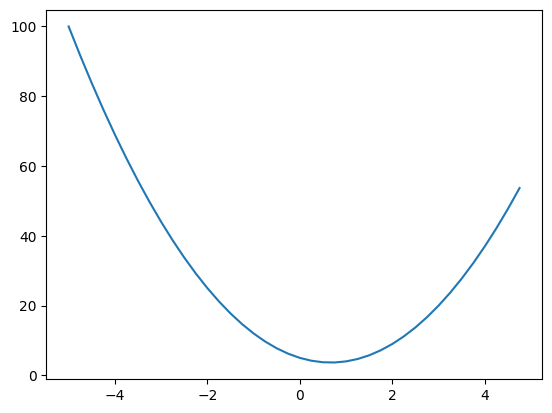

In [21]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs,ys)

In [22]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [23]:
h = 0.000001 # 用一个极小的h近似计算导数
x= 2/3
(f(x+h)-f(x))/h

2.999378523327323e-06

In [29]:
# 另外一个例子

h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d = a*b + c

d1 = a*b + c
c += h #稍微调整一下感兴趣的参数值
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)# 计算斜率（导数），评估感兴趣的参数c对结果d的影响程度
# d1 4.0
# d2 4.0001
# slope 0.9999999999976694

d1 4.0
d2 4.0001
slope 0.9999999999976694


可以看到，c的变化对d的影响程度，近似为1。这符合加法的导数定义，$dd/dc = 1$, c变化多少，d就变化多少。



In [31]:

h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d = a*b + c

d1 = a*b + c
a += h #稍微调整一下感兴趣的参数值，给a一个增量，我们期待函数值会下降
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)# 计算斜率（导数），评估感兴趣的参数c对结果d的影响程度
# d1 4.0
# d2 4.0001
# slope 0.9999999999976694

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


可以看到，a的变化对d的影响程度（敏感程度），近似为-3。这符合乘法的导数定义，$dd/da = b$，b正是-3。

通过以上我们可以建立一个梯度计算的直觉感知。


下面用这段代码可以实现自动计算梯度。后面会有详细的说明。

In [35]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

a = Value(2.0)
a
# Value(data=2.0)

Value(data=2.0)

In [34]:
class Value:
    def __init__(self, data):
        self.data = data

    # def __repr__(self):
    #     return f"Value(data={self.data})"

a = Value(2.0)
a
# <__main__.Value at 0x7fb795589d20> 没有重载__repr__就会返回变量a的内存地址，而不是a的内容

In [41]:
# 定义两个Value对象的加法和乘法运算，借助重载运算符__xxx__实现

class Value:
    
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data)
        return out


a = Value(2.0)
b = Value(3.0)
c = a+b
c
#Value(data=5.0)


Value(data=5.0)

In [43]:
# 也可以手动调用
d = a.__add__(b)
d
#Value(data=5.0)

Value(data=5.0)

In [49]:
# 为了生成计算图，需要记录和维护哪些值生成了其它值的指针信息
class Value:
    
    def __init__(self, data, _children = ()): #使用一个默认为空的元组tuple保存子节点
        self.data = data
        self._prev = set(_children) # 内部实现使用集合set维护，效率考虑

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other)) # out的两个子节点，对应self和other
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out


In [50]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a*b +c

d._prev

{Value(data=-6.0), Value(data=10.0)}

In [51]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

e = a*b
d = e +c

d._prev
# {Value(data=-6.0), Value(data=10.0)}

{Value(data=-6.0), Value(data=10.0)}

In [52]:
# 还需要记录操作符
class Value:
  
  def __init__(self, data, _children=(), _op=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+') 
    

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
      
    return out

In [55]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a*b +c

d._op
# '+'

'+'

我们目前可以完整记录并追溯数学表达式了 。

清晰可视化计算过程，画计算图。

In [64]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

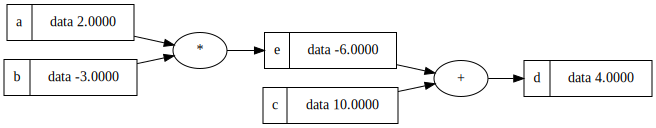

In [70]:
draw_dot(d)

In [68]:
# 为了在计算图上更清晰显示变量名称，在初始化活新建一个变量时将变量名称用字符串表示，增加一个label变量

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
  
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')  
        return out
        

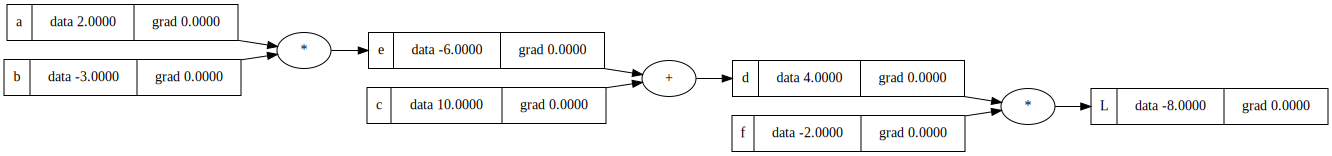

In [96]:
a = Value(2.0, label='a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b
e.label = 'e'
d = e +c
d.label='d'

f= Value(-2.0, label='f')
L = d*f
L.label = 'L'

draw_dot(L)

# L的计算过程就是前向传播

In [97]:
#后向传播，我们从L开始，从后往前，反向逐个计算梯度，计算L关于d,f,e,c,b,a的梯度
# L关于自身的梯度，dL/dL = 1

# 我们需要关注的是a,b,c,d,e,f如何影响最终的L，其中a,b,c,d,e,f有些是参数，有些是输入数据，通过调整参数，在输入数据不变的情况下，尽量减小损失L，优化模型。

# 我们新增一个变量，记录梯度的数值
# 新增一个内部函数，为每个运算操作计算梯度

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda:None
        self.grad = 0.0
        
    def __repr__(self):
        return f"Value(data={self.data})"
  
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # out = a + b
            # dout/da = 1
            # dLoss/da = (dout/da) * (dLoss/dout) 根据复合函数的链式法则
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
            
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')  

        def _backward():
            # out = a * b
            # dout/da = b
            # dLoss/da = (dout/da) * (dLoss/dout) 根据复合函数的链式法则
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        return out


In [98]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

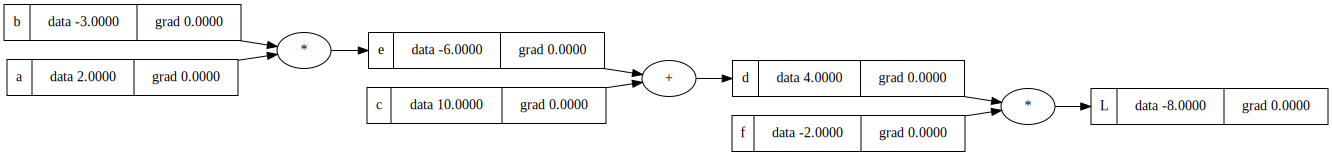

In [99]:
a = Value(2.0, label='a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b
e.label = 'e'
d = e +c
d.label='d'

f= Value(-2.0, label='f')
L = d*f
L.label = 'L'

draw_dot(L)

In [101]:
# 现在开始计算梯度，并且手动填入

#从最末端开始
# L关于自身的梯度dL/dL = 1
# 如果L改变一个微小的h，L会变化多少？

# 手动计算梯度的函数
def lol():

    h = 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b
    e.label = 'e'
    d = e +c
    d.label='d'
    
    f= Value(-2.0, label='f')
    L = d*f
    L.label = 'L'

    L1 =L.data

    a = Value(2.0+h, label='a') ### a + h
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b
    e.label = 'e'
    d = e +c
    d.label='d'
    
    f= Value(-2.0, label='f')
    L = d*f
    L.label = 'L'

    L2 =L.data 

    print((L2-L1)/h)

# dL/da
lol() 
# -6.000000000021544





6.000000000021544


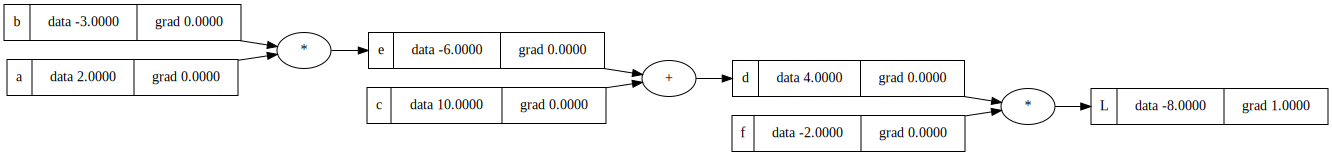

In [102]:
L.grad = 1.0 #手动设置末端的梯度

draw_dot(L)
# 可以看到计算图末端的L梯度已经为1

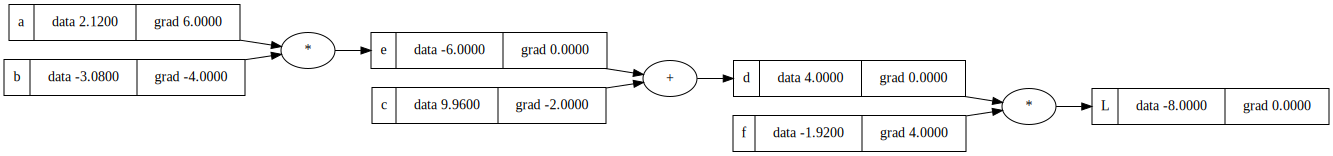

In [115]:
# 接着计算L关于d和f的梯度

# L  = d*f
# dL/df = d, (f(x+h)-f(x))/h ---> (d*(f+h)-d*f)/h = d
# dL/dd = f

# dL/df = 4.0
# dL/dd = -2.0

# dL/dc c如何影响L，我们已经知道d如何影响L，也知道从如何影响d，将这些字儿信息通过某种方式聚集起来，就可以知道c如何影响L

# d = c+e, ---> dd/dc = 1
#               dL/dd = f
# L = (c+e)*f，(f(x+h)-f(x))/h ---> ((c+h+e)*f - (c+e)*f)/h = f, 
# dL/dc = dL/dd * dd/dc =-2.0
# 链式法则
# 汽车是自行车速度的2倍，自行车是行人速度的4倍，那么汽车速度是行人的8倍。一个简单的例子，理解链式法则。

# dL/de = -2.0

# dL/da = dL/de*de/da，---> dL.da = 6

# dL/db = dL/de*de/db，---> dL.da = -4

d.grad = -2.0
f.grad = 4.0
e.grda = -2.0
c.grad = -2.0
b.grad = -4.0
a.grad = 6.0

draw_dot(L)

In [116]:
# 如果我们希望增大L，只需要沿着梯度的方向进行调整
# 0.01是步长
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b

d = e +c

L_new = d*f


L_new.data

-5.900192000000001

In [ ]:
# 增加一些其它运算符

In [117]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
      
  #实现自动计算梯度
  def backward(self):
    
    topo = []
    visited = set()
      
    def build_topo(v):
      if v not in visited:
        visited.add(v) #处理当前节点
        for child in v._prev:
          build_topo(child) #递归的处理子节点
        topo.append(v) #当前节点v处理完成
          
    build_topo(self)# 从自身节点开始，反向传播
    
    self.grad = 1.0 #自身节点关于自己的梯度为1
    for node in reversed(topo):
      node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L
L.backward()

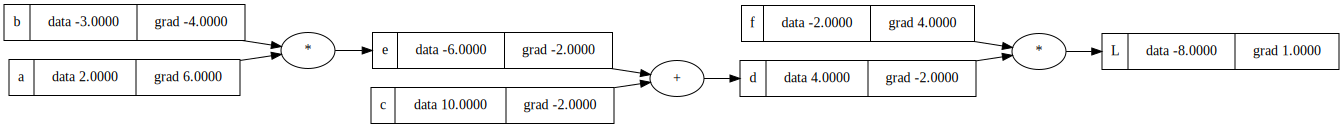

In [118]:
draw_dot(L)